In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import json

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import json

In [4]:
df = pd.read_csv("../../data/raw/raipur_satellite.csv")

df.head()

,system:index,LST,NDBI,NDVI,NDWI,QA_PIXEL,QA_RADSAT,SR_B1,SR_B2,SR_B3,...,ST_ATRAN,ST_B10,ST_CDIST,ST_DRAD,ST_EMIS,ST_EMSD,ST_QA,ST_TRAD,ST_URAD,.geo
0,0,49.324769,0.044834,0.107286,-0.129500,21824.0,0.0,9129.0,9589.5,10869.5,...,6182.0,50753.0,522.0,1518.5,9689.5,92.0,255.0,10817.5,3193.5,"{""type"":""Point"",""coordinates"":[81.559776041052..."
1,1,56.794852,0.045984,0.108955,-0.150005,21824.0,0.0,8906.5,9691.0,11297.5,...,6360.5,52938.5,13969.0,1466.0,9675.0,103.0,237.0,11968.0,3062.5,"{""type"":""Point"",""coordinates"":[81.696184536179..."
2,2,50.919275,0.102545,0.114751,-0.158930,21824.0,0.0,9655.0,10283.5,11953.5,...,6199.5,51219.5,5430.0,1508.5,9641.0,267.0,347.0,11242.5,3171.5,"{""type"":""Point"",""coordinates"":[81.753923539858..."
3,3,46.132338,-0.008944,0.098333,-0.085027,21824.0,0.0,8347.0,8804.0,10083.0,...,6036.0,49819.0,399.0,1556.0,9560.0,313.0,339.0,10597.0,3291.0,"{""type"":""Point"",""coordinates"":[81.674762104758..."
4,4,49.425601,0.028813,0.167497,-0.185644,21824.0,0.0,9012.0,9606.0,11107.0,...,5891.0,50782.5,5632.0,1598.5,9665.5,120.0,306.0,10956.5,3398.0,"{""type"":""Point"",""coordinates"":[81.622394837102..."


In [5]:
df.shape

(2500, 25)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   system:index   2500 non-null   int64  
 1   LST            2500 non-null   float64
 2   NDBI           2500 non-null   float64
 3   NDVI           2500 non-null   float64
 4   NDWI           2500 non-null   float64
 5   QA_PIXEL       2500 non-null   float64
 6   QA_RADSAT      2500 non-null   float64
 7   SR_B1          2500 non-null   float64
 8   SR_B2          2500 non-null   float64
 9   SR_B3          2500 non-null   float64
 10  SR_B4          2500 non-null   float64
 11  SR_B5          2500 non-null   float64
 12  SR_B6          2500 non-null   float64
 13  SR_B7          2500 non-null   float64
 14  SR_QA_AEROSOL  2500 non-null   float64
 15  ST_ATRAN       2500 non-null   float64
 16  ST_B10         2500 non-null   float64
 17  ST_CDIST       2500 non-null   float64
 18  ST_DRAD        2500

In [7]:
df.isnull().sum()

system:index     0
LST              0
NDBI             0
NDVI             0
NDWI             0
QA_PIXEL         0
QA_RADSAT        0
SR_B1            0
SR_B2            0
SR_B3            0
SR_B4            0
SR_B5            0
SR_B6            0
SR_B7            0
SR_QA_AEROSOL    0
ST_ATRAN         0
ST_B10           0
ST_CDIST         0
ST_DRAD          0
ST_EMIS          0
ST_EMSD          0
ST_QA            0
ST_TRAD          0
ST_URAD          0
.geo             0
dtype: int64

In [8]:
df[['LST','NDVI','NDBI','NDWI']].describe()

,LST,NDVI,NDBI,NDWI
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,47.914786,0.140022,0.014221,-0.159113
std,4.401990,0.047311,0.045664,0.042182
min,35.820172,-0.036489,-0.238544,-0.376857
25%,45.156066,0.109666,-0.009191,-0.181952
50%,47.631995,0.134866,0.019638,-0.160118
75%,50.156202,0.163604,0.044782,-0.137063
max,61.368163,0.413858,0.159983,0.041048


In [9]:
def extract_coordinates(geo_string):
    geo = json.loads(geo_string)
    
    longitude = geo["coordinates"][0]
    latitude = geo["coordinates"][1]
    
    return pd.Series([longitude, latitude])


df[['longitude','latitude']] = df['.geo'].apply(extract_coordinates)

df.head()

,system:index,LST,NDBI,NDVI,NDWI,QA_PIXEL,QA_RADSAT,SR_B1,SR_B2,SR_B3,...,ST_CDIST,ST_DRAD,ST_EMIS,ST_EMSD,ST_QA,ST_TRAD,ST_URAD,.geo,longitude,latitude
0,0,49.324769,0.044834,0.107286,-0.129500,21824.0,0.0,9129.0,9589.5,10869.5,...,522.0,1518.5,9689.5,92.0,255.0,10817.5,3193.5,"{""type"":""Point"",""coordinates"":[81.559776041052...",81.559776,21.269197
1,1,56.794852,0.045984,0.108955,-0.150005,21824.0,0.0,8906.5,9691.0,11297.5,...,13969.0,1466.0,9675.0,103.0,237.0,11968.0,3062.5,"{""type"":""Point"",""coordinates"":[81.696184536179...",81.696185,21.134942
2,2,50.919275,0.102545,0.114751,-0.158930,21824.0,0.0,9655.0,10283.5,11953.5,...,5430.0,1508.5,9641.0,267.0,347.0,11242.5,3171.5,"{""type"":""Point"",""coordinates"":[81.753923539858...",81.753924,21.210473
3,3,46.132338,-0.008944,0.098333,-0.085027,21824.0,0.0,8347.0,8804.0,10083.0,...,399.0,1556.0,9560.0,313.0,339.0,10597.0,3291.0,"{""type"":""Point"",""coordinates"":[81.674762104758...",81.674762,21.357004
4,4,49.425601,0.028813,0.167497,-0.185644,21824.0,0.0,9012.0,9606.0,11107.0,...,5632.0,1598.5,9665.5,120.0,306.0,10956.5,3398.0,"{""type"":""Point"",""coordinates"":[81.622394837102...",81.622395,21.179558


In [10]:
df.to_csv(
    "../../data/processed/raipur_features.csv",
    index=False
)

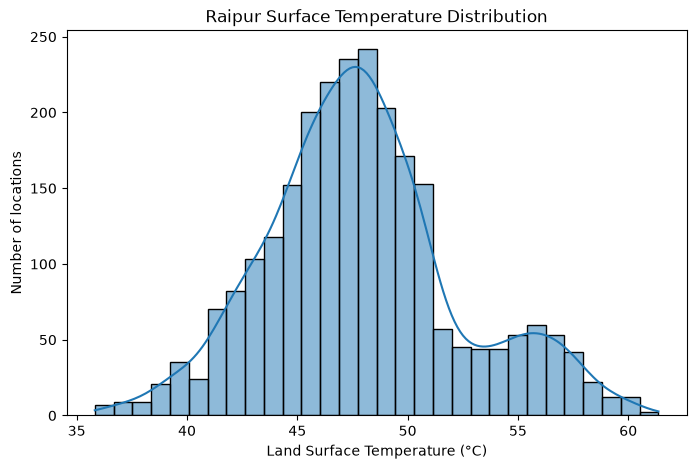

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['LST'],
    bins=30,
    kde=True
)

plt.xlabel("Land Surface Temperature (°C)")
plt.ylabel("Number of locations")
plt.title("Raipur Surface Temperature Distribution")

plt.show()

In [12]:
import folium


raipur_map = folium.Map(
    location=[21.25,81.63],
    zoom_start=11
)


for _, row in df.iterrows():

    folium.CircleMarker(
        location=[
            row['latitude'],
            row['longitude']
        ],
        radius=3,
        color=None,
        fill=True,
        fill_color='red',
        fill_opacity=0.5
    ).add_to(raipur_map)


from IPython.display import display
display(raipur_map)

In [13]:
import folium
from folium.plugins import HeatMap
import branca.colormap as cm

In [14]:
df['LST'].min(), df['LST'].max()

(np.float64(35.82017203999999), np.float64(61.368162530000006))

In [15]:
minimum_temp = df['LST'].min()
maximum_temp = df['LST'].max()


colormap = cm.LinearColormap(
    colors=[
        'green',
        'yellow',
        'orange',
        'red'
    ],
    vmin=minimum_temp,
    vmax=maximum_temp
)

colormap

In [16]:
raipur_heatmap = folium.Map(
    location=[21.2514,81.6296],
    zoom_start=11
)


for _, row in df.iterrows():

    folium.CircleMarker(
        location=[
            row['latitude'],
            row['longitude']
        ],
        radius=5,
        color=colormap(row['LST']),
        fill=True,
        fill_color=colormap(row['LST']),
        fill_opacity=0.7,
        popup=f"""
        Temperature: {row['LST']:.2f} °C <br>
        NDVI: {row['NDVI']:.3f}<br>
        NDBI: {row['NDBI']:.3f}<br>
        NDWI: {row['NDWI']:.3f}
        """
    ).add_to(raipur_heatmap)


colormap.add_to(raipur_heatmap)


raipur_heatmap


In [17]:
df['LST'].min(), df['LST'].max()

(np.float64(35.82017203999999), np.float64(61.368162530000006))

In [18]:
hotspots = df.sort_values(
    by='LST',
    ascending=False
)

hotspots.head(10)

,system:index,LST,NDBI,NDVI,NDWI,QA_PIXEL,QA_RADSAT,SR_B1,SR_B2,SR_B3,...,ST_CDIST,ST_DRAD,ST_EMIS,ST_EMSD,ST_QA,ST_TRAD,ST_URAD,.geo,longitude,latitude
2219,2219,61.368163,0.083365,0.099787,-0.148421,21824.0,0.0,9850.5,10517.5,12146.5,...,14055.0,1470.0,9486.0,417.0,401.5,12312.0,3072.0,"{""type"":""Point"",""coordinates"":[81.648732867303...",81.648733,21.130805
627,627,60.899894,0.069583,0.114654,-0.150794,21824.0,0.0,9245.5,9781.0,11066.0,...,14086.0,1470.0,9653.0,134.0,250.0,12406.0,3070.5,"{""type"":""Point"",""coordinates"":[81.634100295392...",81.634100,21.127731
1528,1528,60.464096,0.067145,0.107840,-0.150287,21824.0,0.0,9430.0,10134.5,11715.0,...,14081.5,1470.5,9652.0,81.0,236.0,12355.5,3072.5,"{""type"":""Point"",""coordinates"":[81.637162065518...",81.637162,21.118805
567,567,60.412826,0.081890,0.098576,-0.152632,21824.0,0.0,9707.0,10291.0,11994.5,...,14114.0,1471.0,9667.0,106.0,241.0,12363.0,3074.0,"{""type"":""Point"",""coordinates"":[81.621639018833...",81.621639,21.118432
1855,1855,60.168438,0.073513,0.096555,-0.146775,21824.0,0.0,9646.5,10340.0,12026.0,...,14124.0,1470.5,9647.0,143.0,252.0,12319.5,3072.0,"{""type"":""Point"",""coordinates"":[81.616186446510...",81.616186,21.128126
841,841,60.165019,0.055354,0.115285,-0.151079,21824.0,0.0,9159.0,9834.0,11321.0,...,14077.0,1469.5,9658.0,147.0,253.0,12328.5,3070.5,"{""type"":""Point"",""coordinates"":[81.638484676103...",81.638485,21.127011
350,350,60.047098,0.086650,0.102796,-0.153524,21824.0,0.0,9633.5,10273.5,11966.0,...,14052.0,1470.0,9671.5,59.0,231.0,12325.5,3072.0,"{""type"":""Point"",""coordinates"":[81.650141908484...",81.650142,21.130398
956,956,59.944557,0.072466,0.088364,-0.129737,21824.0,0.0,9038.0,9618.5,11006.0,...,13997.0,1468.0,9699.0,72.0,233.0,12339.0,3066.5,"{""type"":""Point"",""coordinates"":[81.678123539722...",81.678124,21.144966
60,60,59.934303,0.076434,0.095534,-0.145414,21824.0,0.0,9856.0,10467.5,12130.0,...,14104.0,1470.5,9644.0,109.0,242.0,12290.5,3072.5,"{""type"":""Point"",""coordinates"":[81.626210281176...",81.626210,21.120303
553,553,59.922340,0.090665,0.094505,-0.143582,21824.0,0.0,9565.5,10211.5,11813.0,...,14054.0,1470.0,9680.5,102.0,240.0,12320.5,3071.5,"{""type"":""Point"",""coordinates"":[81.649249870707...",81.649250,21.130978


In [19]:
hotspots.head(100).to_csv(
    "../../data/processed/raipur_hotspots.csv",
    index=False
)

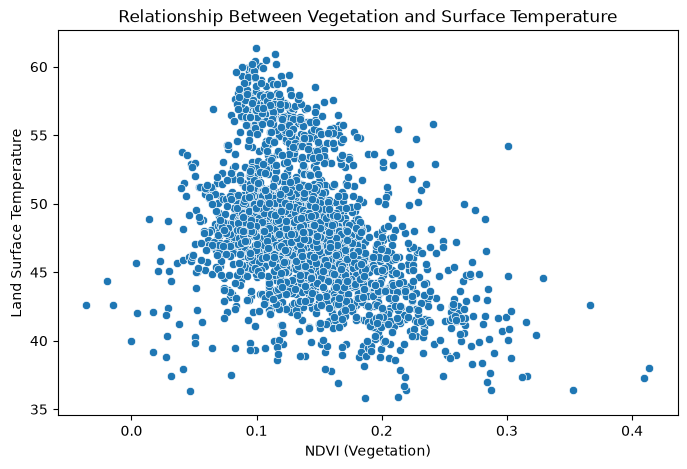

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='NDVI',
    y='LST'
)

plt.title(
    "Relationship Between Vegetation and Surface Temperature"
)

plt.xlabel("NDVI (Vegetation)")
plt.ylabel("Land Surface Temperature")

plt.show()

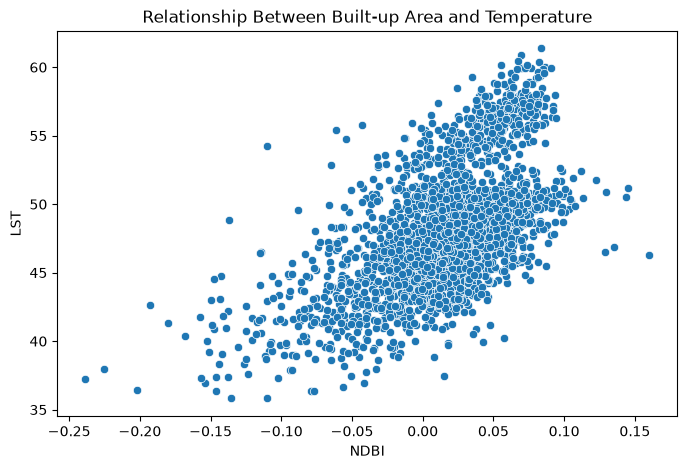

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='NDBI',
    y='LST'
)

plt.title(
    "Relationship Between Built-up Area and Temperature"
)

plt.xlabel("NDBI")
plt.ylabel("LST")

plt.show()

In [22]:
ml_df = df[
    [
        'LST',
        'NDVI',
        'NDBI',
        'NDWI',
        'latitude',
        'longitude'
    ]
]


ml_df.head()

,LST,NDVI,NDBI,NDWI,latitude,longitude
0,49.324769,0.107286,0.044834,-0.129500,21.269197,81.559776
1,56.794852,0.108955,0.045984,-0.150005,21.134942,81.696185
2,50.919275,0.114751,0.102545,-0.158930,21.210473,81.753924
3,46.132338,0.098333,-0.008944,-0.085027,21.357004,81.674762
4,49.425601,0.167497,0.028813,-0.185644,21.179558,81.622395


In [23]:
correlation = ml_df.corr()

correlation

,LST,NDVI,NDBI,NDWI,latitude,longitude
LST,1.000000,-0.394582,0.605556,0.171256,-0.448423,0.241533
NDVI,-0.394582,1.000000,-0.623460,-0.931120,-0.079702,-0.157237
NDBI,0.605556,-0.623460,1.000000,0.380254,-0.184108,0.177609
NDWI,0.171256,-0.931120,0.380254,1.000000,0.251350,0.132876
latitude,-0.448423,-0.079702,-0.184108,0.251350,1.000000,-0.029641
longitude,0.241533,-0.157237,0.177609,0.132876,-0.029641,1.000000


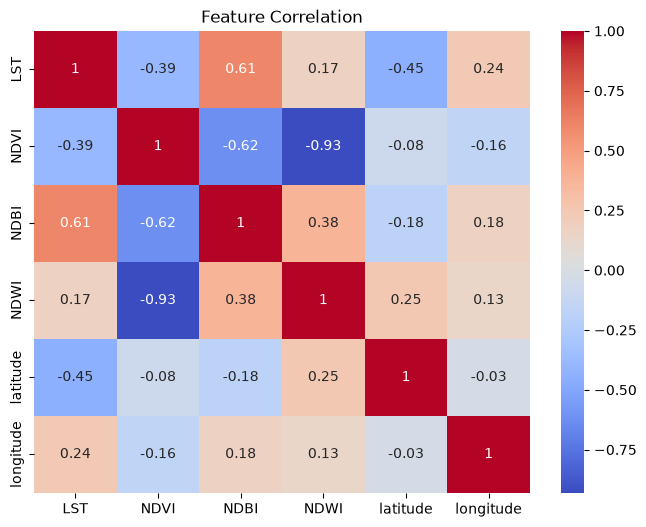

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")
plt.show()

In [25]:
def assign_heat_risk(temp):

    if temp < 40:
        return "Low"

    elif temp < 48:
        return "Medium"

    elif temp < 55:
        return "High"

    else:
        return "Extreme"



ml_df['Heat_Risk'] = ml_df['LST'].apply(assign_heat_risk)


ml_df.head()

,LST,NDVI,NDBI,NDWI,latitude,longitude,Heat_Risk
0,49.324769,0.107286,0.044834,-0.129500,21.269197,81.559776,High
1,56.794852,0.108955,0.045984,-0.150005,21.134942,81.696185,Extreme
2,50.919275,0.114751,0.102545,-0.158930,21.210473,81.753924,High
3,46.132338,0.098333,-0.008944,-0.085027,21.357004,81.674762,Medium
4,49.425601,0.167497,0.028813,-0.185644,21.179558,81.622395,High


In [26]:
ml_df.describe()

,LST,NDVI,NDBI,NDWI,latitude,longitude
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,47.914786,0.140022,0.014221,-0.159113,21.253030,81.633334
std,4.401990,0.047311,0.045664,0.042182,0.067970,0.072190
min,35.820172,-0.036489,-0.238544,-0.376857,21.117185,81.486521
25%,45.156066,0.109666,-0.009191,-0.181952,21.196875,81.574829
50%,47.631995,0.134866,0.019638,-0.160118,21.253621,81.634722
75%,50.156202,0.163604,0.044782,-0.137063,21.308399,81.691828
max,61.368163,0.413858,0.159983,0.041048,21.384542,81.773442


In [27]:
ml_df['Heat_Risk'].value_counts()

Heat_Risk
Medium     1287
High        903
Extreme     233
Low          77
Name: count, dtype: int64

In [28]:
ml_df.to_csv(
    "../../data/processed/raipur_ml_dataset.csv",
    index=False
)